# Library Inclusion and Dataframes

<!-- structured-notebook -->
## Notebook Summary
Purpose: build cross-platform topic groupings by counting documents that match manually defined keyword sets across News, Reddit, and PubMed, then export aligned topic labels for later research-question notebooks.

Main steps:
- Load per-source datasets and define the keyword bundles that stand in for candidate shared topics.
- Count matches and inspect cross-source overlap to see which topics appear comparable across platforms.
- Finalize manual topic-number assignments and export the aligned datasets.


In [ ]:
# structured-notebook-bootstrap
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    return start


_repo_root = find_repo_root(Path.cwd())
if str(_repo_root) not in sys.path:
    sys.path.append(str(_repo_root))

from src.project_paths import (
    ARXIV_RAW_DIR,
    CHROMA_DIR,
    EXTERNAL_NEWS_DIR,
    GUARDIAN_DATA_DIR,
    LLM_CLASSIFICATION_DIR,
    NEWS_HTML_DIR,
    NEWS_OUTPUT_DIR,
    PREPRINT_RAW_DIR,
    PROQUEST_PROCESSED_DIR,
    PROQUEST_UNPROCESSED_DIR,
    PUBMED_PROCESSED_DIR,
    PUBMED_RAW_DIR,
    PUBLICATIONS_TABLE_DIR,
    REDDIT_DATA_DIR,
    ROOT,
    RQ1_FIGURES_DIR,
    RQ4_PLOTS_DIR,
    TOPIC_MATCHING_DIR,
    YOUTUBE_DATA_DIR,
)


In [1]:
import pandas as pd
import numpy as np
import itables.options as opt
from itables import show
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow

In [2]:
news_df = pd.read_csv(PROQUEST_PROCESSED_DIR / 'full_df.csv')
rdt_df = pd.read_parquet(REDDIT_DATA_DIR / 'kept_metadata.parquet')
pm_df = pd.read_parquet(PUBMED_PROCESSED_DIR / 'kept_metadata.parquet')
yt_df = pd.read_csv(YOUTUBE_DATA_DIR / 'cleaned_data.csv')

# Documents per keyword

In [7]:
import re

def find_docs_by_keys(src: str, keys: list):
    pattern = "|".join(re.escape(k.lower()) for k in keys)
    if src == 'n':
        mask = (
            news_df['Title'].str.lower().str.contains(pattern, na=False, regex=True)
            | news_df['Full text'].str.lower().str.contains(pattern, na=False, regex=True)
        )
        return news_df[mask]
    elif src == 'r':
        mask = rdt_df['title'].str.lower().str.contains(pattern, na=False, regex=True)
        return rdt_df[mask]
    elif src == 'p':
        mask = pm_df['title_abstract'].str.lower().str.contains(pattern, na=False, regex=True)
        return pm_df[mask]
    return None

def find_topic_everywhere(key: list):
    n = find_docs_by_keys(src = 'n', keys = key)
    r = find_docs_by_keys(src = 'r', keys = key)
    p = find_docs_by_keys(src = 'p', keys = key)

    return n, r, p

### Topics by News

In [4]:
topics = pd.read_csv(PROQUEST_PROCESSED_DIR / 'topic_info.csv')

***
1. Centenarians/Supercentenarians/Superager/Super-ager
2. Biological age (can try "epigenetic" and see how much of an overlap we get)
3. Senescent cells
4. telomeres/telomerase
5. rapamycin/sirolimus
6. metformin
7. dementia/alzheimers (maybe also cognitive decline/brain health)
8. protein
9. mediterranean diet
10. intermittent fasting
11. retirement/retirees
12. physical activity/walking/sedentary/exercising
13. bryan johnson
14. blue zones
15. sleep/asleep
16. menopause/menopausal
17. curcumin
18. tea (we can try green tea/black tea/coffee altogether since they come as one in my topic from bertopic)
19. testosterone
20. heart disease
21. stem cells/stem
22. yoga
***

***
List of other possible topics:
- nursing or caregiving (might be vague)
- superfood (mainly discussed in news and not used within pubmed)
- red light therapy (not discussed within pubmed at all)
- wine (almost not discussed within pubmed)
- hrt (hormone replacement therapy, almost not discussed within pubmed)
- resveratrol (good topic)
- probiotic (good topic)
- gut microbiome (good topic)
- autophagy (good topic)
- caenorhabditis (good topic) or nematode
- meditation (good for reddit and news)
- alkaline or sodium (needs to be reviewed)
- geneediting ('geneediting', 'gene-editing', 'gene editing', 'genetic engineering', 'synthetic biology') - good topic
- adaaptogen (good for news and reddit)
- nicotine (might need to be reviewed again)
- optimism (might be good)
- calorie restriction (good topic)
- nicotinamide (good topic)
- adenine (good topic)
- cannabis or marijuana (good topic)
- hearing loss (good for news and reddit)
- ozempic (good for news and reddit)
- weight loss (good topic)
- blueberry or raspberry (good for news and reddit)
- nootropic (good topic)
- modafinil (good topic)
- hyperbaric oxygen (good topic)
- sirt1 or sirt3 (good topic)
- enzyme (good topic)
- chocolate (a bit vague)
- obesity (good topic)
- HIIT (good for enws and reddit)
- turmeric (good for reddit and news)
- cryotherapy or ice bath or cold water (good for reddit and news)
- strength training (good for news and reddit)
- beta carotene or omega3 or fish oil or fatty acid (good topic, could be separated)
- walnut or almond or peanut (good for news and reddit)
- potassium (good topic)
- olive oil (good for news and reddit)
- vitamin b12 (good topic)
- cardiovascular disease (good topic)
- chronic stress (good for news and reddit)
- cortisol (good for news and reddit)
- oxidative stress (good topic)
***

### Topics by Reddit

In [84]:
keys = [
    #News    
    ['Centenarian', 'Supercentenarian', 'Superager', 'Super-ager'],
    ['Senescent cell', 'senolytics'],
    ['Telomere', 'telomerase'],
    ['rapamycin', 'sirolimus'],
    ['metformin'],
    ['dementia', 'alzheimer', 'cognitive decline', 'brain health'],
    ['mediterranean'],
    ['intermittent fasting'],
    ['retirement'],
    ['bryan johnson'],
    ['blue zone'],
    ['circadian rhythm'],
    ['menopause'],
    ['curcumin'],
    ['green tea'],
    ['yoga'],

    ['nursing', 'caregiving'],
    ['superfood'],
    ['red light therapy', 'light therapy'],
    ['wine'],
    ['hrt', 'trt'],
    ['resveratrol'],
    ['probiotic'],
    ['autophagy'],
    ['caenorhabditis', 'nematode'],
    ['meditation'],
    ['alkaline', 'sodium'],
    ['geneediting', 'gene-editing', 'gene editing', 'genetic engineering', 'synthetic biology'],
    ['adaptogen'],
    ['nicotine'],
    ['optimism'],
    ['calorie restriction'],
    ['nicotinamide'],
    ['adenine'],
    ['hearing loss'],
    ['ozempic'],
    ['weight loss'],
    ['blueberry', 'raspberry'],
    ['nootropic'],
    ['modafinil'],
    ['hyperbaric oxygen'],
    ['sirt1', 'sirt3'],
    ['enzyme'],
    ['chocolate'],
    ['obesity'],
    ['HIIT'],
    ['turmeric'],
    ['cryotherapy', 'ice bath', 'cold water', 'cold shower'],
    ['strength training', 'exercise', 'fitness', 'physical activity', 'sedentary', 'walking', 'muscle mass'],
    ['beta carotene', 'omega3', 'fish oil', 'fatty acid'],
    ['walnut','almond','peanut'],
    ['potassium'],
    ['olive oil'],
    ['vitamin b12'],
    ['cardiovascular disease'],
    ['chronic stress'],
    ['cortisol'],
    ['oxidative stress'],

    #Reddit
    ['creatine'],
    ['biohacking'],
    ['joint health'],
    ['organic food'],
    ['blood test'],
    ['immortality'],
    ['sauna'],
    ['tinnitus'],
    ['gut health'],
    ['magnesium'],
    ['proteostasis'],
    ['cholesterol'],
    ['cancer'],
    ['modafinil'],
    
    ['coronavirus', 'covid19'],
    
    ['epigenetic', 'methylation'],
    
    ['caffeine'],
    ['adenosine'],
    
    ['neutrophils'],
    
    ['mitochondria', 'mitophagy'],
        
    ['stem cell'],
    ['regenerative medicine'],

    ['blood sugar', 'diabete', 'blood glucose'],
    
    ['gut microbiome', 'gut microbiota', 'gut bacteria', 'gut health'],

    ['cannabis', 'marijuana'],
    ['psychedelics'],

    ['sarcopenia'],
    ['sceletal muscle'],

    ['geriatrics']
]

topic_counts = []

for key in keys:
    n, r, p = find_topic_everywhere(key)

    news_ids = n['ProQuest document ID'].tolist()
    reddit_ids = r['unique_index'].tolist()
    pubmed_ids = p['pmid'].tolist()
    
    topic_counts.append([key, len(n), len(r), len(p), str(news_ids), str(reddit_ids), str(pubmed_ids)])

In [85]:
topics = pd.DataFrame(topic_counts, columns = ['Keys', 'News Length', 'Reddit Length', 'PubMed Length', 'News Doc IDs', 'Reddit Doc IDs', 'PubMed Doc IDs'])

In [86]:
topics.to_csv(TOPIC_MATCHING_DIR / "topic_counts.csv", index=False)

<!-- structured-notebook -->
## Overlap Diagnostic
This block converts the saved match lists into overlap statistics and a Jaccard-style heatmap. It is mainly used to see which keyword bundles behave like coherent cross-platform topics.


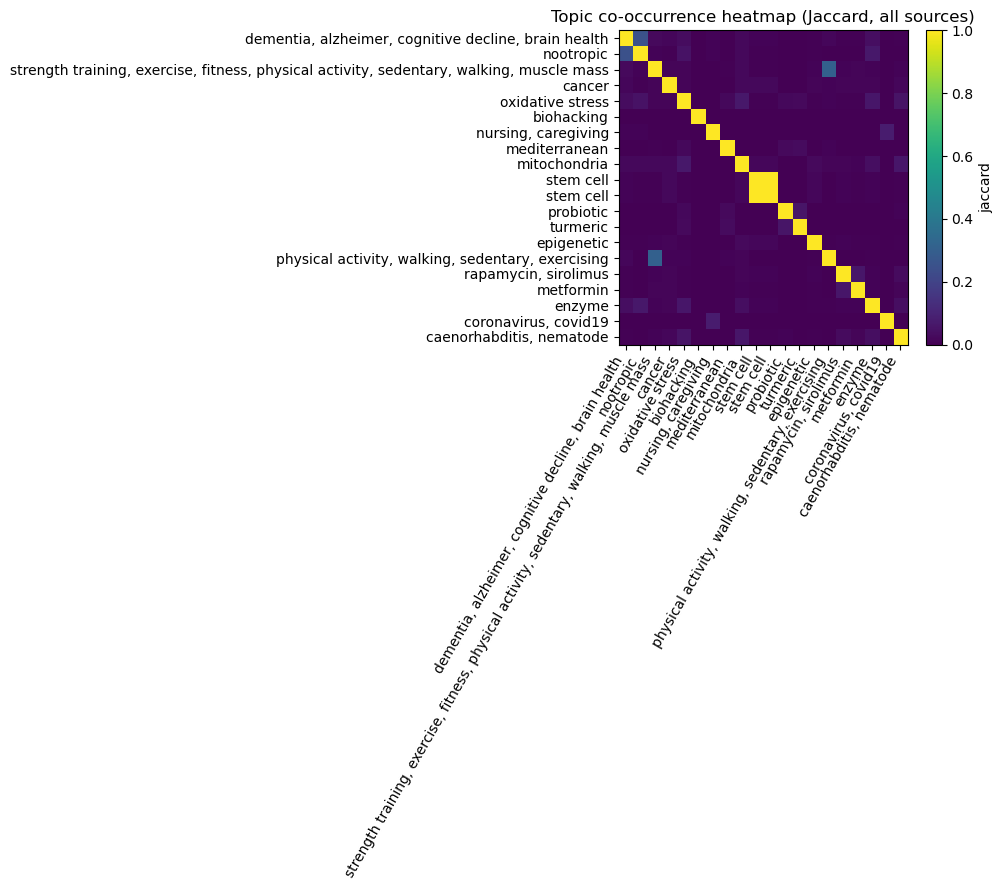

'jaccard_heatmap_all_sources_top20.png'

In [74]:
# Build a Jaccard heatmap (Matplotlib, no seaborn) of topic overlap.
# Strategy: select the top 20 topics by total "all_sources" set size for readability.
import pandas as pd, numpy as np, ast
import matplotlib.pyplot as plt

# --- Load & parse ---
df = pd.read_csv(TOPIC_MATCHING_DIR / "topic_counts.csv")

def parse_list_to_set(x):
    try:
        lst = ast.literal_eval(str(x))
        return set(str(s).strip().strip("'").strip('"').strip() for s in lst if str(s).strip())
    except Exception:
        return set()

for col in ["News Doc IDs", "Reddit Doc IDs", "PubMed Doc IDs"]:
    df[f"{col}__set"] = df[col].apply(parse_list_to_set)

# Make a label for each topic (comma-joined keys)
def topic_label(val, i):
    try:
        keys = ast.literal_eval(val)
        return ", ".join(keys)
    except Exception:
        return f"topic_{i}"

df["Topic"] = [topic_label(v, i) for i, v in enumerate(df["Keys"].tolist())]
df["ALL__set"] = df.apply(lambda r: r["News Doc IDs__set"] | r["Reddit Doc IDs__set"] | r["PubMed Doc IDs__set"], axis=1)
df["all_size"] = df["ALL__set"].apply(len)

# --- choose top-N topics for readability ---
TOP_N = 20
top = df.sort_values("all_size", ascending=False).head(TOP_N).reset_index(drop=True)

# --- compute Jaccard matrix on ALL__set ---
n = len(top)
jmat = np.zeros((n, n), dtype=float)
for i in range(n):
    A = top.loc[i, "ALL__set"]
    for j in range(n):
        B = top.loc[j, "ALL__set"]
        inter = len(A & B)
        uni = len(A | B) if (A or B) else 0
        jmat[i, j] = (inter/uni) if uni else 0.0

labels = top["Topic"].tolist()

# --- Plot heatmap ---
plt.figure(figsize=(10, 9))
im = plt.imshow(jmat, aspect='auto')  # default colormap
plt.xticks(range(n), labels, rotation=60, ha='right')
plt.yticks(range(n), labels)
plt.title("Topic co-occurrence heatmap (Jaccard, all sources)")
plt.colorbar(im, label="jaccard")
plt.tight_layout()
out_path = NEWS_OUTPUT_DIR / "figures" / "jaccard_heatmap_all_sources_top20.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

out_path


Centenarians: Centenarian, Supercentenarian, Superager, Super-ager

Exercise & physical activity: strength training, exercise, fitness, physical activity, sedentary, walking, muscle mass

Gut microbiome: gut microbiome, gut microbiota, gut bacteria, gut health

Metformin: metformin

Rapamycin and sirolimus: rapamycin, sirolimus

Cellular senescence & senolytics: Senescent cell, senolytics

Telomere biology: telomere, telomerase

Epigenetics / methylation: epigenetic, methylation

Mitochondria & mitophagy: mitochondria, mitophagy

Sirtuins (SIRT1/SIRT3): sirtuins, sirt1, sirt3

Autophagy: autophagy

Diabetes & glycemic control: blood sugar, diabete, blood glucose

Cardiovascular disease: cardiovascular disease

Obesity: obesity

Cancer: cancer

Dementia / Alzheimer’s / cognitive decline: dementia, alzheimer, cognitive decline, brain health

Nootropics / modafinil: modafinil, nootropics

In [ ]:
show(topics[['Keys', 'News Length', 'Reddit Length', 'PubMed Length']])

# Pairing documents

<!-- structured-notebook -->
## Final Manual Alignment
The cells below turn the keyword bundles into the discrete topic mappings used later in `RQ1` and `RQ4`. Read them as a hand-curated alignment layer rather than a fully automatic classifier.


In [8]:
chosen_keys = [
    ['Centenarian', 'Supercentenarian', 'Superager', 'Super-ager'],
    ['Senescent cell', 'senolytics'],
    ['Telomere', 'telomerase'],
    ['rapamycin', 'sirolimus'],
    ['metformin'],
    ['dementia', 'alzheimer', 'cognitive decline', 'brain health'],
    ['strength training', 'exercise', 'fitness', 'physical activity', 'sedentary', 'walking', 'muscle mass'],
    ['blood sugar', 'diabete', 'blood glucose'],
    ['gut microbiome', 'gut microbiota', 'gut bacteria', 'gut health'],
    ['epigenetic', 'methylation'],
    ['mitochondria', 'mitophagy'],
    ['sirtuins', 'sirt1', 'sirt3'],
    ['autophagy'],
    ['cardiovascular disease'],
    ['obesity'],
    ['cancer'],
    ['modafinil', 'nootropic']
]

n_df = pd.DataFrame()
r_df = pd.DataFrame()
p_df = pd.DataFrame()

for i, key in enumerate(chosen_keys):
    n, r, p = find_topic_everywhere(key)

    n['topic'] = str(key)
    r['topic'] = str(key)
    p['topic'] = str(key)
    n['topic_num'] = i
    r['topic_num'] = i
    p['topic_num'] = i


    n_df = pd.concat([n_df, n], ignore_index=True)
    r_df = pd.concat([r_df, r], ignore_index=True)
    p_df = pd.concat([p_df, p], ignore_index=True)

/tmp/ipykernel_6814/1169599556.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n['topic'] = str(key)
/tmp/ipykernel_6814/1169599556.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['topic'] = str(key)
/tmp/ipykernel_6814/1169599556.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retur

***
Might be deleted:
- cancer
- blood sugar
- centenarian
***

In [12]:
yt_df.loc[yt_df['keywords']=='cardiovascular disease', 'topic_num'] = 13
yt_df.loc[yt_df['keywords']=='sirtuins', 'topic_num'] = 11
yt_df.loc[yt_df['keywords']=='gut microbiome', 'topic_num'] = 8
yt_df.loc[yt_df['keywords']=='metformin', 'topic_num'] = 4
yt_df.loc[yt_df['keywords']=='cancer', 'topic_num'] = 15
yt_df.loc[yt_df['keywords']=='exercise & physical activity', 'topic_num'] = 6
yt_df.loc[yt_df['keywords']=='epigenetic and methylation', 'topic_num'] = 9
yt_df.loc[yt_df['keywords']=='cellular senescence & senolytics', 'topic_num'] = 1
yt_df.loc[yt_df['keywords']=='dementia and alzheimer', 'topic_num'] = 5
yt_df.loc[yt_df['keywords']=='autophagy', 'topic_num'] = 12
yt_df.loc[yt_df['keywords']=='rapamycin and sirolimus', 'topic_num'] = 3
yt_df.loc[yt_df['keywords']=='mitochondria & mitophagy', 'topic_num'] = 10
yt_df.loc[yt_df['keywords']=='diabetes & glycemic control', 'topic_num'] = 7
yt_df.loc[yt_df['keywords']=='telomere biology', 'topic_num'] = 2
yt_df.loc[yt_df['keywords']=='centenarians', 'topic_num'] = 0
yt_df.loc[yt_df['keywords']=='obesity', 'topic_num'] = 14
yt_df.loc[yt_df['keywords']=='modafinil and nootropics', 'topic_num'] = 16

In [13]:
n_df.to_csv(TOPIC_MATCHING_DIR / 'news_with_topics.csv', index=False)
r_df.to_csv(TOPIC_MATCHING_DIR / 'reddit_with_topics.csv', index=False)
p_df.to_csv(TOPIC_MATCHING_DIR / 'pubmed_with_topics.csv', index=False)
yt_df.to_csv(TOPIC_MATCHING_DIR / 'youtube_with_topics.csv', index=False)